In [1]:
from sklearn.datasets import make_circles
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

In [2]:
n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [3]:
circles = pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


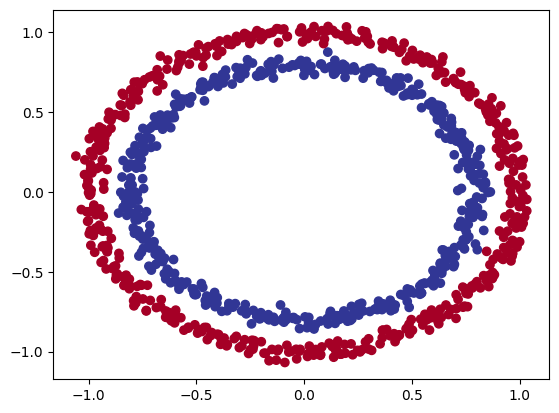

In [4]:
plt.scatter(x=circles["X1"], y=circles["X2"], c=y, cmap=plt.cm.RdYlBu)

In [5]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [8]:
class CircleModelV0(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)
        
    def forward(self, x):
        return self.layer_2(self.layer_1(x))
    
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [9]:
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.0144],
        [-0.2071],
        [ 0.1346],
        [-0.0552],
        [-0.4307],
        [-0.5440],
        [-0.6385],
        [-0.7188],
        [ 0.1583],
        [-0.2263]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [10]:
#lossfn = torch.nn.BCELoss() # No sigmoid
lossfn = torch.nn.BCEWithLogitsLoss() # sigmoid built-in

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [11]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [12]:
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0144],
        [-0.2071],
        [ 0.1346],
        [-0.0552],
        [-0.4307]], device='cuda:0', grad_fn=<SliceBackward0>)

In [13]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4964],
        [0.4484],
        [0.5336],
        [0.4862],
        [0.3940]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [14]:
y_preds = torch.round(y_pred_probs)

y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device)))[:5])

print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 0.], device='cuda:0', grad_fn=<SqueezeBackward0>)

In [15]:
torch.manual_seed(42)

epochs = 100

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
    
    model_0.train()
    
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = lossfn(y_logits, y_train)
    
    acc = accuracy_fn(y_train, y_pred)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    model_0.eval()
    
    with torch.inference_mode():
        
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        test_loss = lossfn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)
        
        if epoch % 10:
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}%")

Epoch: 1 | Loss: 0.71172, Accuracy: 48.00% | Test loss: 0.70460, Test accuracy: 49.00%
Epoch: 2 | Loss: 0.71065, Accuracy: 48.12% | Test loss: 0.70377, Test accuracy: 49.50%
Epoch: 3 | Loss: 0.70965, Accuracy: 48.38% | Test loss: 0.70300, Test accuracy: 49.00%
Epoch: 4 | Loss: 0.70873, Accuracy: 48.75% | Test loss: 0.70229, Test accuracy: 49.50%
Epoch: 5 | Loss: 0.70787, Accuracy: 48.62% | Test loss: 0.70164, Test accuracy: 49.00%
Epoch: 6 | Loss: 0.70708, Accuracy: 48.50% | Test loss: 0.70104, Test accuracy: 50.00%
Epoch: 7 | Loss: 0.70634, Accuracy: 48.38% | Test loss: 0.70049, Test accuracy: 49.50%
Epoch: 8 | Loss: 0.70565, Accuracy: 48.50% | Test loss: 0.69998, Test accuracy: 49.50%
Epoch: 9 | Loss: 0.70501, Accuracy: 48.25% | Test loss: 0.69951, Test accuracy: 50.50%
Epoch: 11 | Loss: 0.70384, Accuracy: 48.38% | Test loss: 0.69867, Test accuracy: 49.50%
Epoch: 12 | Loss: 0.70332, Accuracy: 48.50% | Test loss: 0.69829, Test accuracy: 49.50%
Epoch: 13 | Loss: 0.70283, Accuracy: 48.5

In [17]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


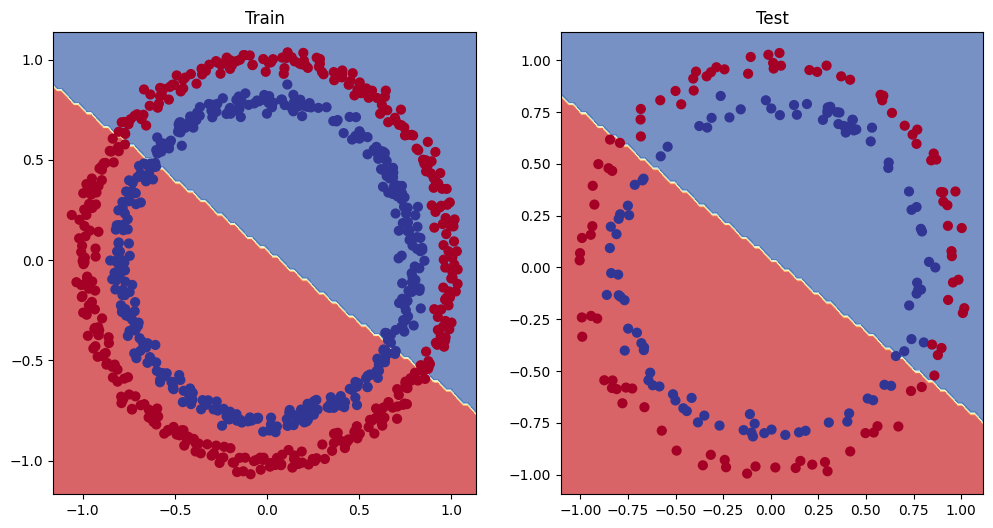

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [ ]:
class CircleModelV1(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        
    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
lossfn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [ ]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
    
    model_1.train()
    
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = lossfn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    model_1.eval()
    
    with torch.inference_mode():
        
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        test_loss = lossfn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)
        
    if epoch % 10:
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}%")    

Epoch: 1 | Loss: 0.69392, Accuracy: 50.50% | Test loss: 0.69262, Test accuracy: 50.50%
Epoch: 2 | Loss: 0.69389, Accuracy: 50.62% | Test loss: 0.69263, Test accuracy: 50.50%
Epoch: 3 | Loss: 0.69386, Accuracy: 50.62% | Test loss: 0.69263, Test accuracy: 50.50%
Epoch: 4 | Loss: 0.69383, Accuracy: 50.62% | Test loss: 0.69264, Test accuracy: 50.50%
Epoch: 5 | Loss: 0.69381, Accuracy: 50.88% | Test loss: 0.69265, Test accuracy: 51.00%
Epoch: 6 | Loss: 0.69378, Accuracy: 50.62% | Test loss: 0.69266, Test accuracy: 51.00%
Epoch: 7 | Loss: 0.69376, Accuracy: 50.12% | Test loss: 0.69267, Test accuracy: 50.50%
Epoch: 8 | Loss: 0.69373, Accuracy: 50.00% | Test loss: 0.69268, Test accuracy: 50.50%
Epoch: 9 | Loss: 0.69371, Accuracy: 50.00% | Test loss: 0.69269, Test accuracy: 50.00%
Epoch: 11 | Loss: 0.69367, Accuracy: 50.25% | Test loss: 0.69272, Test accuracy: 50.00%
Epoch: 12 | Loss: 0.69365, Accuracy: 50.38% | Test loss: 0.69273, Test accuracy: 50.00%
Epoch: 13 | Loss: 0.69363, Accuracy: 50.0

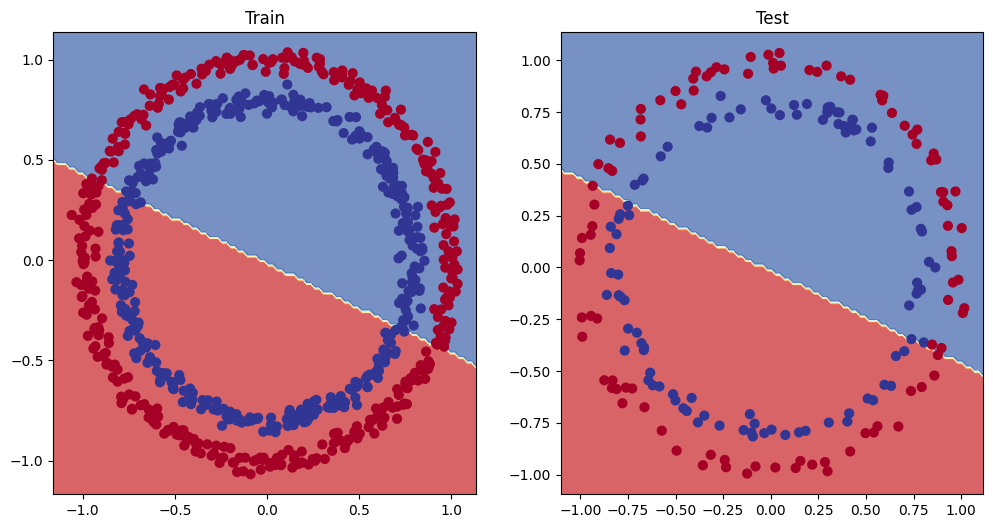

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [ ]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias
X_regression[:5], y_regression[:5]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
train_split = int(len(X_regression) * 0.8)
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

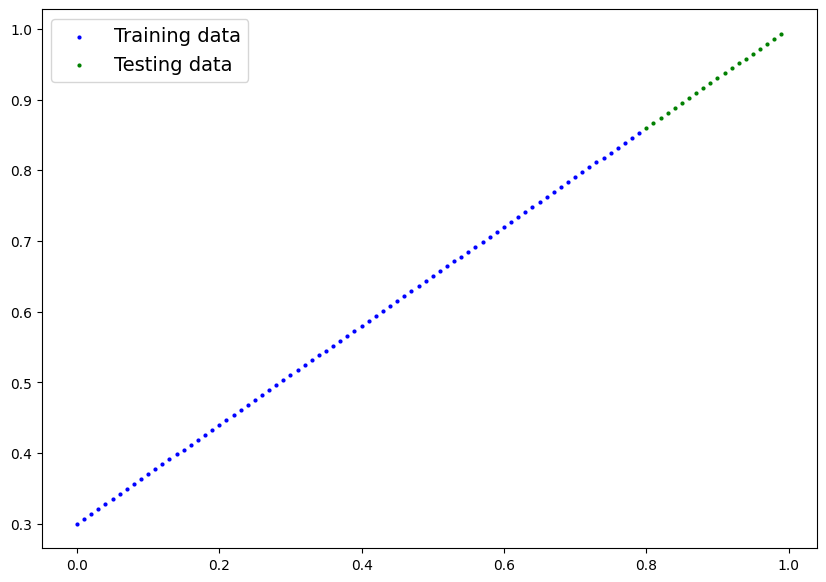

In [ ]:
plot_predictions(train_data=X_train_regression, train_labels=y_train_regression, test_data=X_test_regression, test_labels=y_test_regression)

In [ ]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features= 10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
    ).to(device)

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

In [ ]:
torch.manual_seed(42)

epochs = 1000

X_train_regression, X_test_regression = X_train_regression.to(device), X_test_regression.to(device)
y_train_regression, y_test_regression = y_train_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    
    model_2.train()
    
    y_preds = model_2(X_train_regression)
    
    loss = loss_fn(y_preds, y_train_regression)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    model_2.eval()
    
    with torch.inference_mode():
        
        test_preds = model_2(X_test_regression)
        
        test_loss = loss_fn(test_preds, y_test_regression)
    
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.75986, Test loss: 0.54143
Epoch: 100 | Train loss: 0.09309, Test loss: 0.02901
Epoch: 200 | Train loss: 0.07376, Test loss: 0.02850
Epoch: 300 | Train loss: 0.06745, Test loss: 0.00615
Epoch: 400 | Train loss: 0.06107, Test loss: 0.02004
Epoch: 500 | Train loss: 0.05698, Test loss: 0.01061
Epoch: 600 | Train loss: 0.04857, Test loss: 0.01326
Epoch: 700 | Train loss: 0.06109, Test loss: 0.02127
Epoch: 800 | Train loss: 0.05599, Test loss: 0.01426
Epoch: 900 | Train loss: 0.05571, Test loss: 0.00603


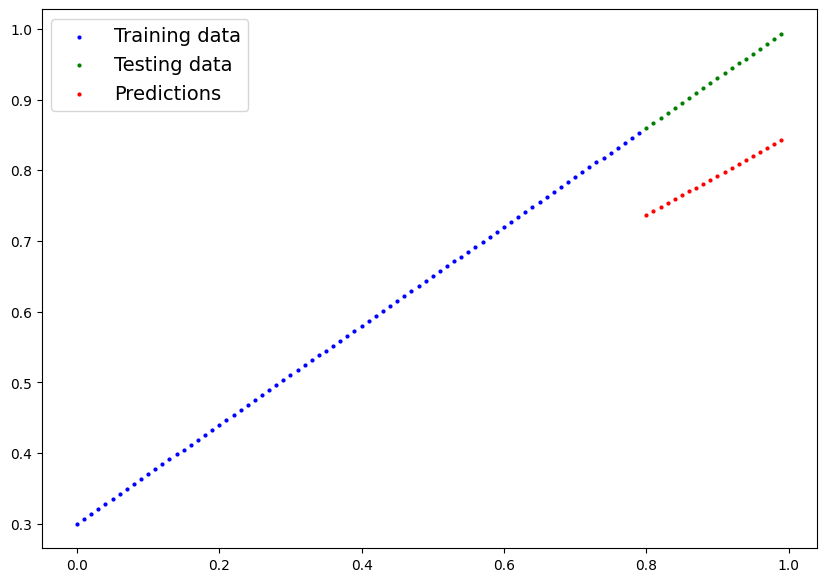

In [ ]:
with torch.inference_mode():
    
    y_preds = model_2(X_test_regression)

plot_predictions(train_data=X_train_regression.cpu(), train_labels=y_train_regression.cpu(), test_data=X_test_regression.cpu(), test_labels=y_test_regression.cpu(), predictions=y_preds.cpu())

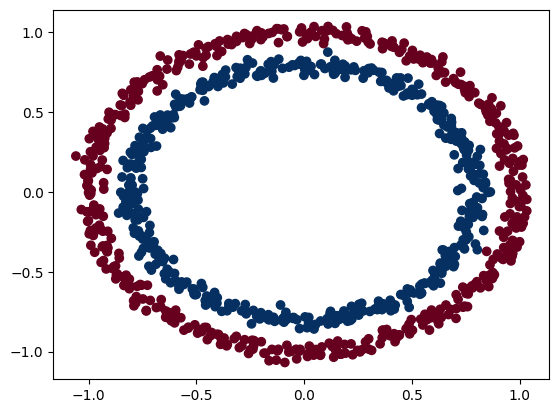

In [ ]:
n_samples = 1000

X, y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdBu)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train[:5], y[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
class CircleModelV2(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

In [ ]:
torch.manual_seed(42)

epochs = 1000

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
    
    model_3.train()
    
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    model_3.eval()
    
    with torch.inference_mode():
        
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)
    
    if epoch % 100:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}%")  
    

Epoch: 1 | Loss: 0.69289, Accuracy: 50.00% | Test loss: 0.69312, Test accuracy: 50.00%
Epoch: 2 | Loss: 0.69284, Accuracy: 50.00% | Test loss: 0.69305, Test accuracy: 50.00%
Epoch: 3 | Loss: 0.69279, Accuracy: 50.00% | Test loss: 0.69299, Test accuracy: 50.00%
Epoch: 4 | Loss: 0.69274, Accuracy: 50.00% | Test loss: 0.69292, Test accuracy: 50.00%
Epoch: 5 | Loss: 0.69268, Accuracy: 50.00% | Test loss: 0.69286, Test accuracy: 50.00%
Epoch: 6 | Loss: 0.69264, Accuracy: 50.00% | Test loss: 0.69280, Test accuracy: 50.00%
Epoch: 7 | Loss: 0.69259, Accuracy: 50.00% | Test loss: 0.69274, Test accuracy: 50.00%
Epoch: 8 | Loss: 0.69255, Accuracy: 50.00% | Test loss: 0.69269, Test accuracy: 50.00%
Epoch: 9 | Loss: 0.69251, Accuracy: 50.38% | Test loss: 0.69264, Test accuracy: 50.00%
Epoch: 10 | Loss: 0.69248, Accuracy: 50.50% | Test loss: 0.69260, Test accuracy: 50.00%
Epoch: 11 | Loss: 0.69244, Accuracy: 51.00% | Test loss: 0.69255, Test accuracy: 50.00%
Epoch: 12 | Loss: 0.69242, Accuracy: 51.5

In [ ]:
model_3.eval()

with torch.inference_mode():
    
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
    
y_preds[:10], y[:10]

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

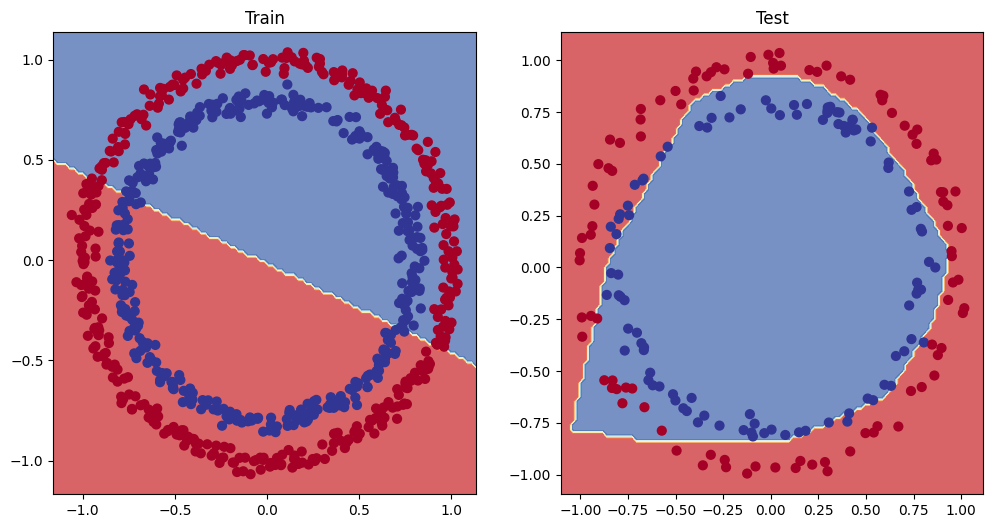

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

In [ ]:
A = torch.arange(-10, 10, 1, dtype=torch.float)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

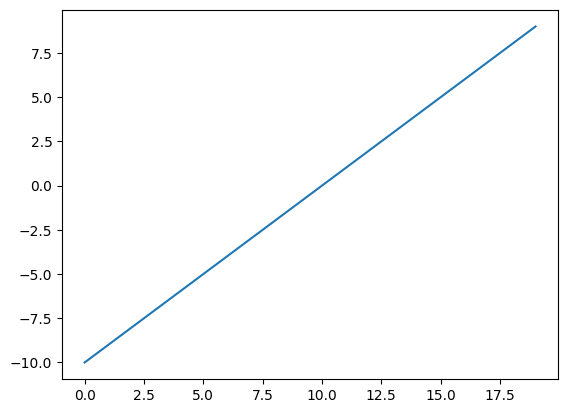

In [ ]:
plt.plot(A)

In [ ]:
def relu(x):
    return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

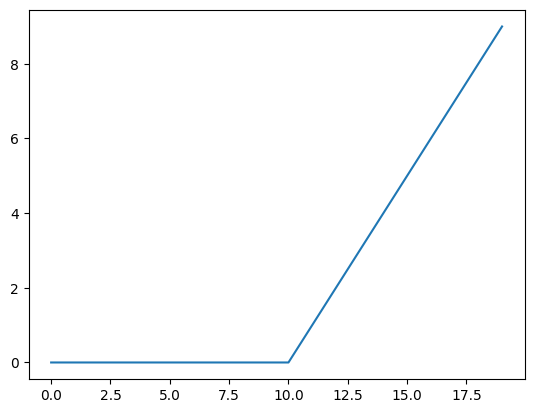

In [ ]:
plt.plot(relu(A))

In [ ]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

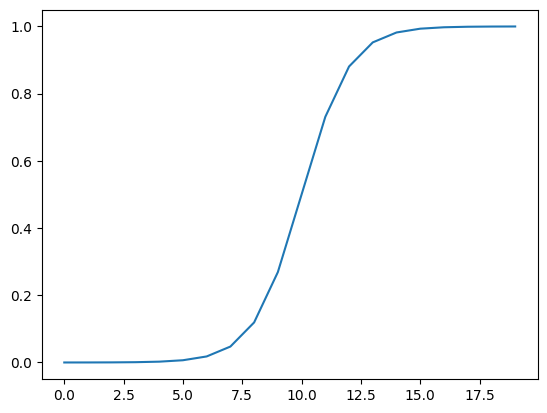

In [ ]:
plt.plot(sigmoid(A))

In [ ]:
from sklearn.datasets import make_blobs

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000, n_features=NUM_FEATURES, centers=NUM_CLASSES, cluster_std=1.5, random_state=RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, train_size=0.8, random_state=RANDOM_SEED)


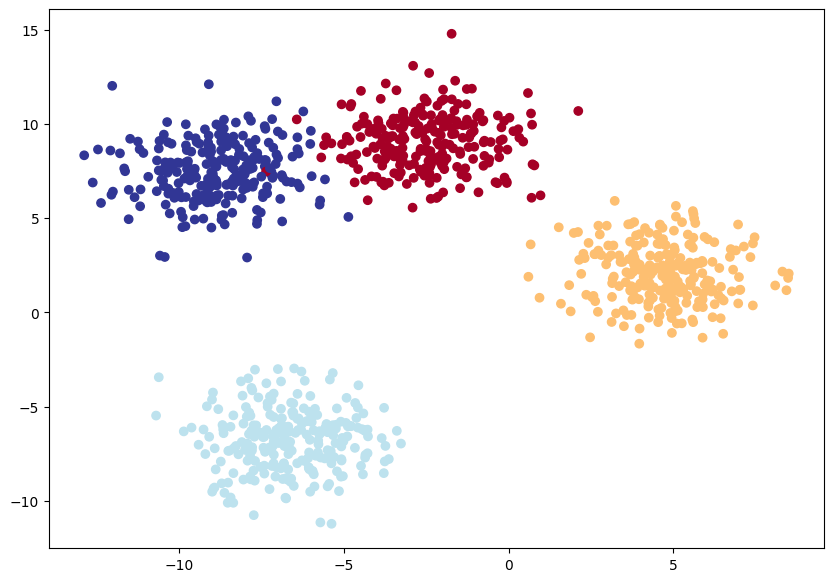

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c= y_blob, cmap=plt.cm.RdYlBu)

In [ ]:
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            # nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            # nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
    
    def forward(self, x):
        return self.linear_stack(x)
    
model_4 = BlobModel(NUM_FEATURES, NUM_CLASSES).to(device)
model_4

BlobModel(
  (linear_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(), lr=0.1)

In [ ]:
y_logits = model_4(X_blob_test.to(device))

y_pred_probs = torch.softmax(y_logits, dim=1)
y_logits[:5], y_pred_probs[:5]

(tensor([[ 0.6929,  0.3745,  0.9411, -0.1624],
         [ 1.2381, -0.3169, -1.7294,  1.1252],
         [-1.3281, -0.4334, -0.2821, -0.3388],
         [ 0.1306,  0.2698,  0.9969, -0.3752],
         [ 1.7246,  0.1816, -0.4318,  0.7531]], device='cuda:0',
        grad_fn=<SliceBackward0>),
 tensor([[0.2912, 0.2118, 0.3732, 0.1238],
         [0.4639, 0.0980, 0.0239, 0.4143],
         [0.1113, 0.2724, 0.3169, 0.2994],
         [0.1949, 0.2240, 0.4635, 0.1175],
         [0.5855, 0.1251, 0.0678, 0.2216]], device='cuda:0',
        grad_fn=<SliceBackward0>))

In [ ]:
torch.sum(y_pred_probs[0])

tensor(1., device='cuda:0', grad_fn=<SumBackward0>)

In [ ]:
y_pred_probs[0], torch.argmax(y_pred_probs[0])

(tensor([0.2912, 0.2118, 0.3732, 0.1238], device='cuda:0',
        grad_fn=<SelectBackward0>),
 tensor(2, device='cuda:0'))

In [ ]:
torch.manual_seed(42)

epochs = 100

X_blob_train, X_blob_test = X_blob_train.to(device), X_blob_test.to(device)
y_blob_train, y_blob_test = y_blob_train.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    
    model_4.train()
    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_pred, y_blob_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model_4.eval()
    
    with torch.inference_mode():
   
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
     
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy_fn(y_true=y_blob_test,
                             y_pred=test_pred)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")
        

Epoch: 0 | Loss: 0.02256, Acc: 99.38% | Test Loss: 0.01137, Test Acc: 99.50%
Epoch: 10 | Loss: 0.02254, Acc: 99.38% | Test Loss: 0.01135, Test Acc: 99.50%
Epoch: 20 | Loss: 0.02252, Acc: 99.38% | Test Loss: 0.01132, Test Acc: 99.50%
Epoch: 30 | Loss: 0.02250, Acc: 99.38% | Test Loss: 0.01130, Test Acc: 99.50%
Epoch: 40 | Loss: 0.02248, Acc: 99.38% | Test Loss: 0.01128, Test Acc: 99.50%
Epoch: 50 | Loss: 0.02245, Acc: 99.50% | Test Loss: 0.01125, Test Acc: 99.50%
Epoch: 60 | Loss: 0.02243, Acc: 99.50% | Test Loss: 0.01123, Test Acc: 99.50%
Epoch: 70 | Loss: 0.02241, Acc: 99.50% | Test Loss: 0.01121, Test Acc: 99.50%
Epoch: 80 | Loss: 0.02239, Acc: 99.50% | Test Loss: 0.01118, Test Acc: 99.50%
Epoch: 90 | Loss: 0.02237, Acc: 99.50% | Test Loss: 0.01116, Test Acc: 99.50%


In [ ]:
model_4.eval()

with torch.inference_mode():
    
    y_pred = torch.softmax(model_4(X_blob_test), dim=1).argmax(dim=1)
    
print(f"Predictions: {y_pred[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_pred)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Test accuracy: 99.5%


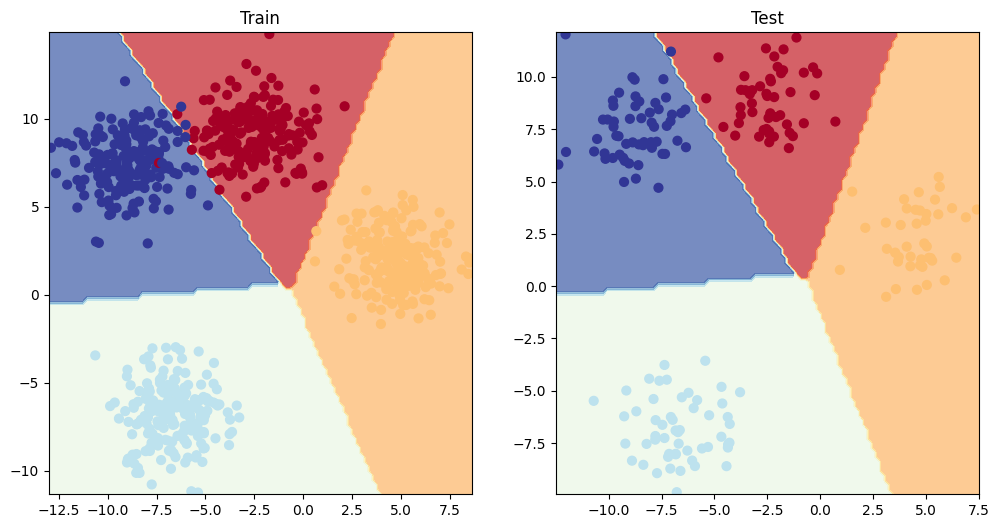

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)